In [1]:
#%pip install -r requirements.txt for first run
import pandas as pd, numpy as np

intraday_window=5
orderbook_data = pd.read_csv('/workspaces/polymarket-signal/orderbook_merged.csv')
orderbook_data['TIMESTAMP'] = pd.to_datetime(orderbook_data['TIMESTAMP'])
orderbook_data = orderbook_data.replace('', np.nan)
orderbook_data

,KEY,REL_HOUR,TIME_TO_EXP,UP_DOWN,TIMESTAMP,MAKER,TAKER,SHARES,USDC,PRICE,...,stock_open_day,stock_close_day,stock_close_5m,stock_high_5m,stock_low_5m,stock_open_5m,stock_volume_5m,stock_avg_5m,returns,stock_vol_5m
0,AAPL,0.882222,23.117778,DOWN,2026-02-02 21:52:56,0x50893670841372c06a625d9f24fa303afc519754,0x95ec5157e205fc39aa5cfc78a6c4d2155515501d,8.1818,18.1818,0.450,...,269.228088,268.948351,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,AAPL,0.882222,23.117778,UP,2026-02-02 21:52:56,0x95ec5157e205fc39aa5cfc78a6c4d2155515501d,0x4bfb41d5b3570defd03c39a9a4d8de6bd8b8982e,10.0000,18.1818,0.550,...,269.228088,268.948351,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,AAPL,1.874444,22.125556,UP,2026-02-02 22:52:28,0xc3cff162bf358d805157d23ea13c8e485c4a1e59,0x4bfb41d5b3570defd03c39a9a4d8de6bd8b8982e,1.0000,1.8182,0.550,...,269.228088,268.948351,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,AAPL,1.874444,22.125556,DOWN,2026-02-02 22:52:28,0x50893670841372c06a625d9f24fa303afc519754,0xc3cff162bf358d805157d23ea13c8e485c4a1e59,0.8182,1.8182,0.450,...,269.228088,268.948351,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,AAPL,5.481111,18.518889,DOWN,2026-02-03 02:28:52,0x50893670841372c06a625d9f24fa303afc519754,0x4bfb41d5b3570defd03c39a9a4d8de6bd8b8982e,19.9900,10.9945,0.550,...,269.228088,268.948351,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
116541,TSLA,0.004722,23.995278,UP,2026-04-09 20:00:17,0xc7a778043fab3ca910fbf95a2f4956cc727f9f02,0x4bfb41d5b3570defd03c39a9a4d8de6bd8b8982e,9.0000,9.0090,0.999,...,348.950012,346.290008,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
116542,TSLA,0.005833,23.994167,DOWN,2026-04-09 20:00:21,0x6dbaac4a5fcf80482dcf534423d1283287e689bc,0x4aac816a4aa83520b4718b6cf2617e8040c9ced2,0.0010,0.9900,0.001,...,348.950012,346.290008,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
116543,TSLA,0.005833,23.994167,DOWN,2026-04-09 20:00:21,0x4aac816a4aa83520b4718b6cf2617e8040c9ced2,0x4bfb41d5b3570defd03c39a9a4d8de6bd8b8982e,0.9900,0.0010,0.001,...,348.950012,346.290008,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
116544,TSLA,0.079167,23.920833,UP,2026-04-09 20:04:45,0xc4ca43d6909192021cac77bea7b0ad07acc23df3,0x1608951f51f83eac87546396b69ea2fc9bb1eeb8,159.8400,160.0000,0.999,...,348.950012,346.290008,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [2]:
clean_orderbook = orderbook_data.dropna().reset_index(drop=True); exchange = clean_orderbook['TAKER'].value_counts().index[0] #by count
volume_by_taker = clean_orderbook.groupby('TAKER')['USDC'].sum(); top_taker = volume_by_taker.idxmax() #by volume (just to double check)
clean_orderbook = clean_orderbook[clean_orderbook['TAKER']!=exchange].reset_index(drop=True)
print(exchange) #checked on polygonscan
print(top_taker)
print(clean_orderbook.columns)
print(clean_orderbook.shape)
clean_orderbook

0x4bfb41d5b3570defd03c39a9a4d8de6bd8b8982e
0x4bfb41d5b3570defd03c39a9a4d8de6bd8b8982e
Index(['KEY', 'REL_HOUR', 'TIME_TO_EXP', 'UP_DOWN', 'TIMESTAMP', 'MAKER',
       'TAKER', 'SHARES', 'USDC', 'PRICE', 'PRICE_UP', 'BUY_SELL', 'log_odds',
       'country', 'stock_open_day', 'stock_close_day', 'stock_close_5m',
       'stock_high_5m', 'stock_low_5m', 'stock_open_5m', 'stock_volume_5m',
       'stock_avg_5m', 'returns', 'stock_vol_5m'],
      dtype='str')
(53564, 24)


,KEY,REL_HOUR,TIME_TO_EXP,UP_DOWN,TIMESTAMP,MAKER,TAKER,SHARES,USDC,PRICE,...,stock_open_day,stock_close_day,stock_close_5m,stock_high_5m,stock_low_5m,stock_open_5m,stock_volume_5m,stock_avg_5m,returns,stock_vol_5m
0,AAPL,19.516667,4.483333,DOWN,2026-02-03 16:31:00,0x4254354429e2ac0123744bfa81f2dbee2b6e1182,0x969fae0a3a93778adc42178f72c612ed8c4e4d55,10.00,6.60,0.660,...,269.228088,268.948351,269.609985,268.549988,269.549988,268.899994,291924.0,269.236654,0.000482,0.374184
1,AAPL,19.570556,4.429444,UP,2026-02-03 16:34:14,0x5fe50c22621779e031322c5becb110d1fa0d8b99,0x969fae0a3a93778adc42178f72c612ed8c4e4d55,10.00,3.00,0.300,...,269.228088,268.948351,269.609985,268.549988,269.549988,268.899994,291924.0,269.236654,0.000482,0.374184
2,AAPL,19.666667,4.333333,DOWN,2026-02-03 16:40:00,0xb7fa0d0a47dab8e381f13997f0240c9763cd89e2,0x2910eda74b54235302360007be2832dea91dec9c,52.00,100.00,0.520,...,269.228088,268.948351,270.500000,269.720093,269.734985,270.209992,750436.0,269.985026,0.000925,0.367842
3,AAPL,19.666667,4.333333,DOWN,2026-02-03 16:40:00,0x969fae0a3a93778adc42178f72c612ed8c4e4d55,0x2910eda74b54235302360007be2832dea91dec9c,122.20,260.00,0.470,...,269.228088,268.948351,270.500000,269.720093,269.734985,270.209992,750436.0,269.985026,0.000925,0.367842
4,AAPL,19.752778,4.247222,DOWN,2026-02-03 16:45:10,0x2910eda74b54235302360007be2832dea91dec9c,0xca531aa496adedafba8b6c953bd959d4a7ff17fd,2.80,5.00,0.560,...,269.228088,268.948351,269.980011,269.595001,269.649994,269.760010,232872.0,269.741669,-0.001924,0.363500
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
53559,TSLA,23.986389,0.013611,DOWN,2026-04-09 19:59:11,0x4aac816a4aa83520b4718b6cf2617e8040c9ced2,0x6e7153806c150c8d69432104d07664bf67ed5436,0.03,30.03,0.001,...,345.619995,343.149994,345.799988,344.750000,345.589996,345.510010,1260184.0,345.379995,-0.000318,0.171324
53560,TSLA,23.989722,0.010278,DOWN,2026-04-09 19:59:23,0x4aac816a4aa83520b4718b6cf2617e8040c9ced2,0xc7a778043fab3ca910fbf95a2f4956cc727f9f02,0.07,69.97,0.001,...,345.619995,343.149994,345.799988,344.750000,345.589996,345.510010,1260184.0,345.379995,-0.000318,0.171324
53561,TSLA,23.989722,0.010278,DOWN,2026-04-09 19:59:23,0x0061f603a457754bae0241f1fb34f0ce6a5e8fd6,0xc7a778043fab3ca910fbf95a2f4956cc727f9f02,0.20,200.00,0.001,...,345.619995,343.149994,345.799988,344.750000,345.589996,345.510010,1260184.0,345.379995,-0.000318,0.171324
53562,TSLA,23.989722,0.010278,UP,2026-04-09 19:59:23,0x34f3d3b49f792072530fc545cd37ba77f61dcbd3,0xc7a778043fab3ca910fbf95a2f4956cc727f9f02,50.00,49.95,0.999,...,345.619995,343.149994,345.799988,344.750000,345.589996,345.510010,1260184.0,345.379995,-0.000318,0.171324


In [3]:
from setup.analysis_functions import collapse_to_windows, check_lead_lag

df_5m = collapse_to_windows(orderbook_data, minutes=intraday_window)
df_5m = check_lead_lag(df_5m)

Overall lead correlation: 0.0846
Lead correlation by asset:
KEY
AAPL     0.097767
AMZN     0.095267
GOOGL    0.084321
META     0.094829
MSFT     0.071621
NFLX     0.091920
NVDA     0.072198
TSLA     0.080930
dtype: float64 

------------------------------ 

Overall lag correlation: 0.0010
Lag correlation by asset:
KEY
AAPL    -0.015801
AMZN     0.019244
GOOGL   -0.007372
META     0.042856
MSFT    -0.016796
NFLX     0.007052
NVDA     0.011690
TSLA    -0.037455
dtype: float64


In [4]:
from setup.analysis_functions import lead_lag_ccf

lead_lag_ccf(df_5m)

X^poly → future price (lead):

0    0.084602
1    0.076532
2    0.074234
3    0.067581
4    0.064332
5    0.060697
dtype: float64 

---------------------------------------- 

price → Future X^poly (lag):

0    0.001026
1   -0.004904
2    0.009516
3   -0.008006
4    0.004616
5   -0.009628
dtype: float64


In [5]:
from setup.analysis_functions import sum_stats

sum_stats(df_5m)


,count,mean,std,min,25%,50%,75%,max
true_sentiment,13484.0,-0.0620,0.4512,-0.9990,-0.4370,-0.0402,0.3000,0.9990
abs_sentiment,13484.0,0.3760,0.2570,0.0000,0.1600,0.3800,0.4945,0.9990
avg_trade,13484.0,62.3054,224.5591,0.0050,6.0000,17.4508,55.1250,11156.9441
poly_vol_imbalance,13484.0,-0.0027,0.3325,-1.0000,-0.0225,0.0000,0.0282,1.0000
next_stock_move,13468.0,-0.0000,0.0036,-0.0855,-0.0012,-0.0001,0.0010,0.1031
stock_vol,13484.0,0.2674,0.2261,0.0548,0.1398,0.2019,0.3183,3.2346
time_to_exp,13484.0,3.2876,2.0002,0.0003,1.4644,3.3022,5.0858,23.9256
total_volume,13484.0,481.4664,2991.4480,0.0100,20.9175,89.9822,358.9528,220140.9700
trade_count,13484.0,6.9689,8.3792,1.0000,2.0000,4.0000,8.0000,191.0000


In [6]:
from setup.analysis_functions import analyse_sentiment_dynamics

analyse_sentiment_dynamics(df_5m, intraday_window=intraday_window)


--- IN-SAMPLE (TRAIN) ---
percentile      | min abs conviction | hit rate (%) | N
------------------------------------------------------------
all signals     |               0.0000 |       52.63% | 9590
top 50%         |               0.3496 |       54.14% | 4795
top 25%         |               0.4887 |       54.34% | 2398
top 9%          |               0.6500 |       57.98% | 959
top 5%          |               0.7716 |       62.08% | 480

--- OUT-OF-SAMPLE (TEST) ---
percentile      | min abs conviction | hit rate (%) | N
------------------------------------------------------------
all signals     |               0.0000 |       53.83% | 3223
top 50%         |               0.3856 |       53.29% | 1612
top 25%         |               0.4900 |       53.02% | 811
top 9%          |               0.6685 |       56.97% | 323
top 5%          |               0.7954 |       58.64% | 162

results from polymarket sentiment on price change OLS (OUT-OF-SAMPLE):

          const  true_sentiment

In [7]:
from setup.backtest_graphs_functions import pro_backtest

results_df, stats = pro_backtest(df_5m, leverage=1, min_confidence=0.8, bp_cost=5, risk_free_ann=0.04, strategy='long-short', intraday_window_min=intraday_window)

=== pro backtest [5m] ===
Total return: 9.56%
Sharpe ratio: 1.68
Max drawdown: 1.39%
Win rate:     54.61%
Exp return:   $1.86
Hit rate:     60.14%
Net gain:     $956.22
Total fees:   $1063.14
Total trades: 286

--- ASSET BREAKDOWN (Net PnL) ---
       Net PnL ($)  Contribution (%)
AMZN    244.375071          2.443751
NFLX    164.252173          1.642522
TSLA    113.494329          1.134943
META     95.651481          0.956515
AAPL     27.579402          0.275794
NVDA     21.793462          0.217935
GOOGL   -20.778656         -0.207787
MSFT    -93.721502         -0.937215

Asset breadth: 6/8 assets were profitable!


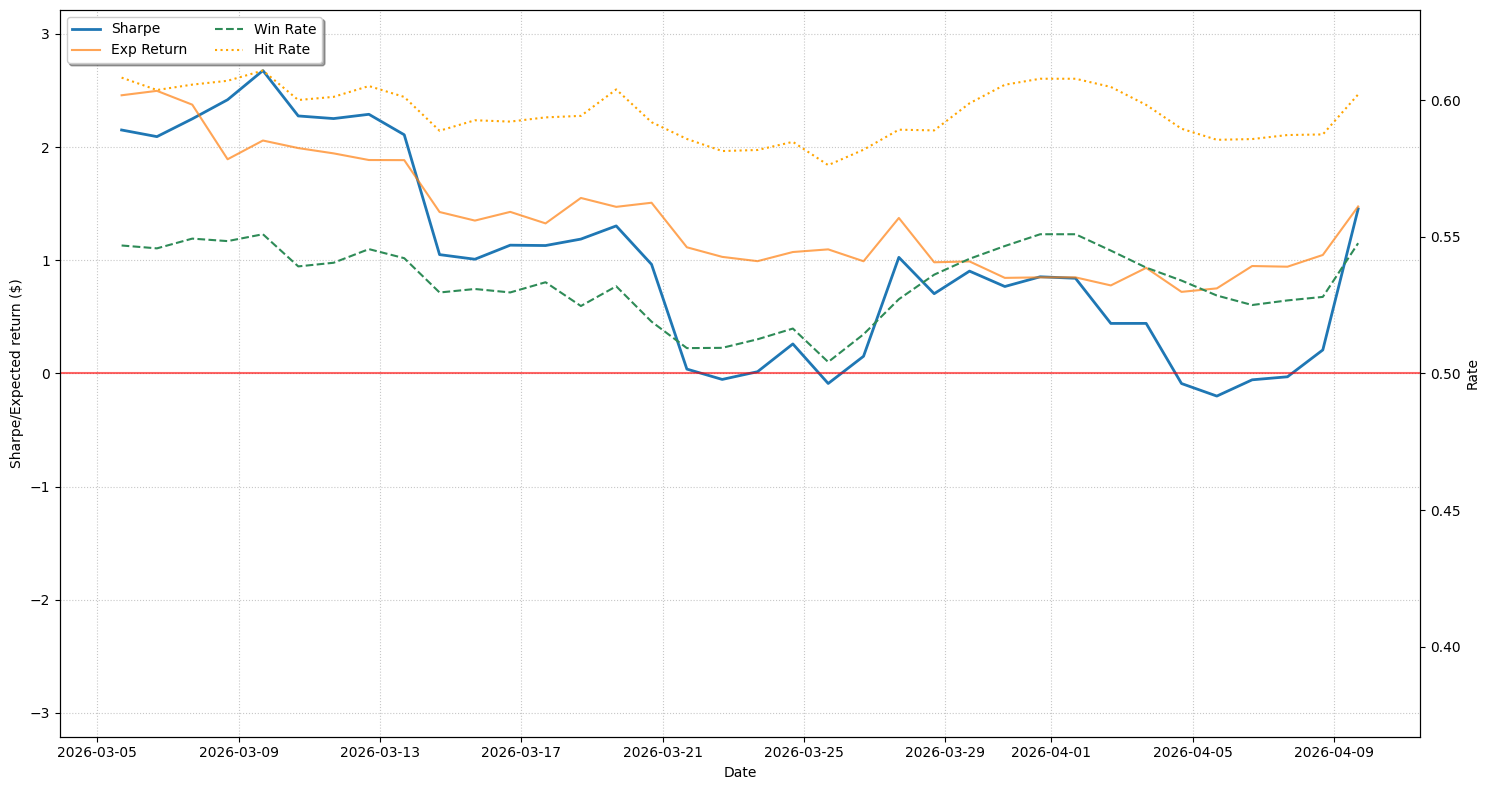

In [8]:
from setup.backtest_graphs_functions import rolling_backtest_plot

rolling_backtest_plot(df_5m, min_confidence= 0.8, bp_cost= 5, include_exp_value=True)

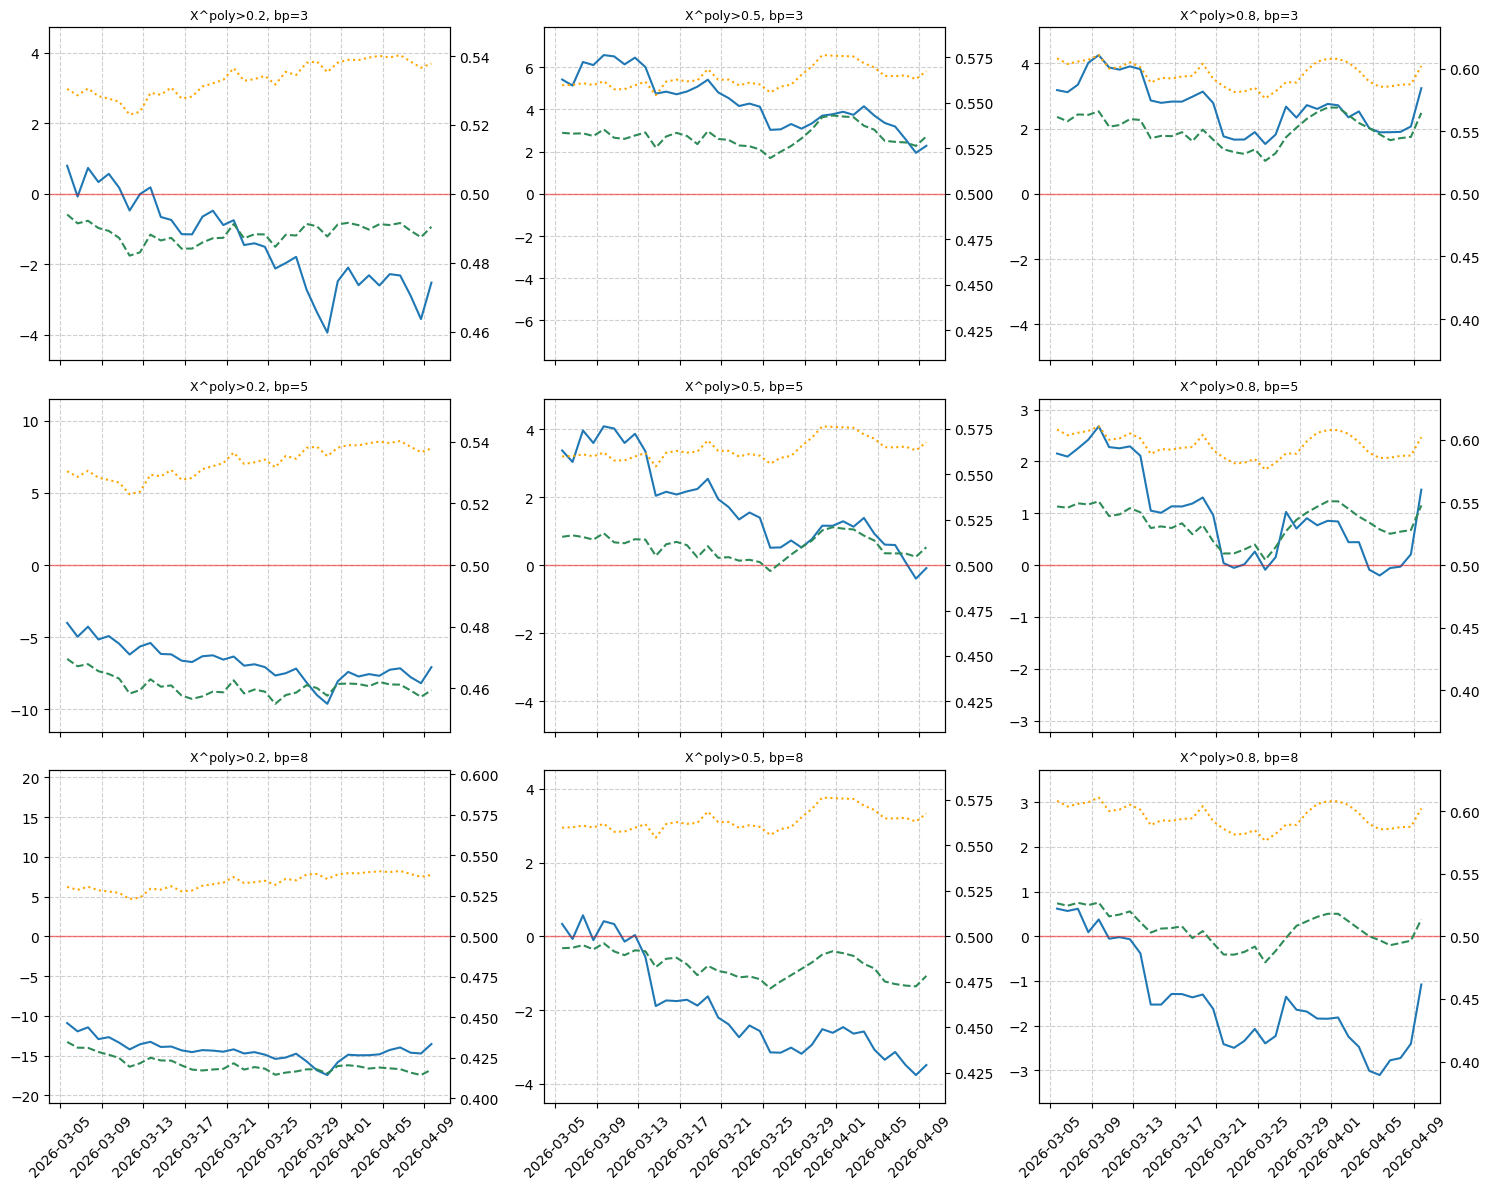

In [9]:
from setup.backtest_graphs_functions import rolling_backtest_grid

rolling_backtest_grid(df_5m, min_conf_list=[0.2, 0.5, 0.8], bp_cost_list=[3, 5, 8], include_exp_value=False)

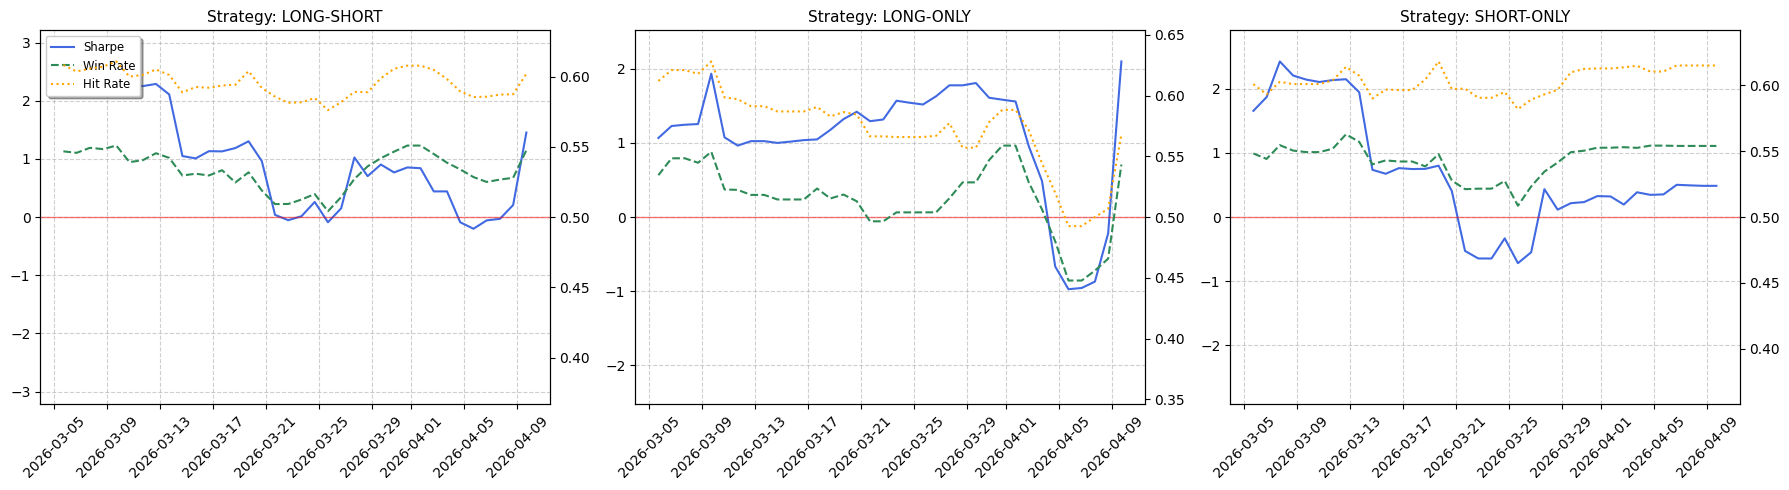

In [10]:
from setup.backtest_graphs_functions import rolling_backtest_grid_by_strategy

rolling_backtest_grid_by_strategy(df_5m, strategies=['long-short', 'long-only', 'short-only'], min_confidence=0.8, bp_cost=5, include_exp_value=False)

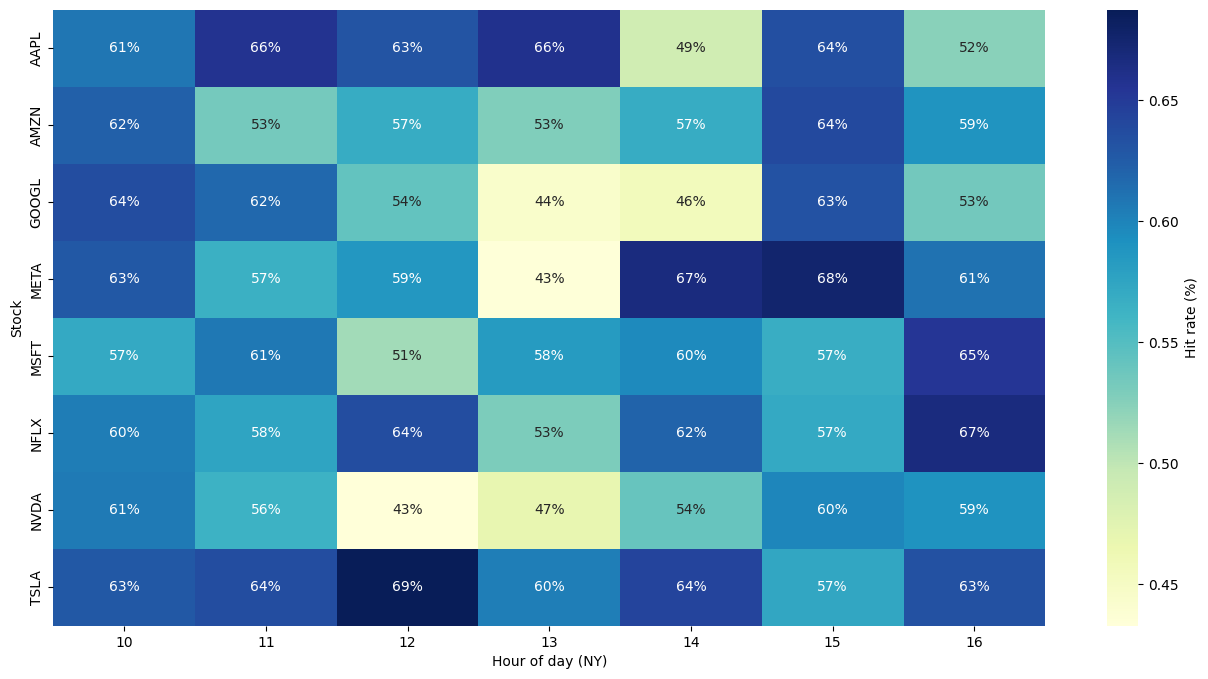

In [11]:
from setup.backtest_graphs_functions import plot_hit_rate_heatmap

plot_hit_rate_heatmap(df_5m)